In [1]:
import torch
import torch.nn as nn
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset

import sys
sys.path.append("..")

In [2]:
print(torch.__version__)

2.11.0+cu128


In [3]:
train_path = r"../data/inaturalist_12K/train"
val_path = r"../data/inaturalist_12K/val"

print(len(os.listdir(train_path)))
print(len(os.listdir(val_path)))

10
10


In [4]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

count = 0

for root, dirs, files in os.walk(val_path):
    for file in files:
        if file.endswith(image_extensions):
            count += 1

print("Total train images:", count)

Total train images: 2000


In [5]:
for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

Amphibia 1000
Animalia 1000
Arachnida 1000
Aves 1000
Fungi 999
Insecta 1000
Mammalia 1000
Mollusca 1000
Plantae 1000
Reptilia 1000


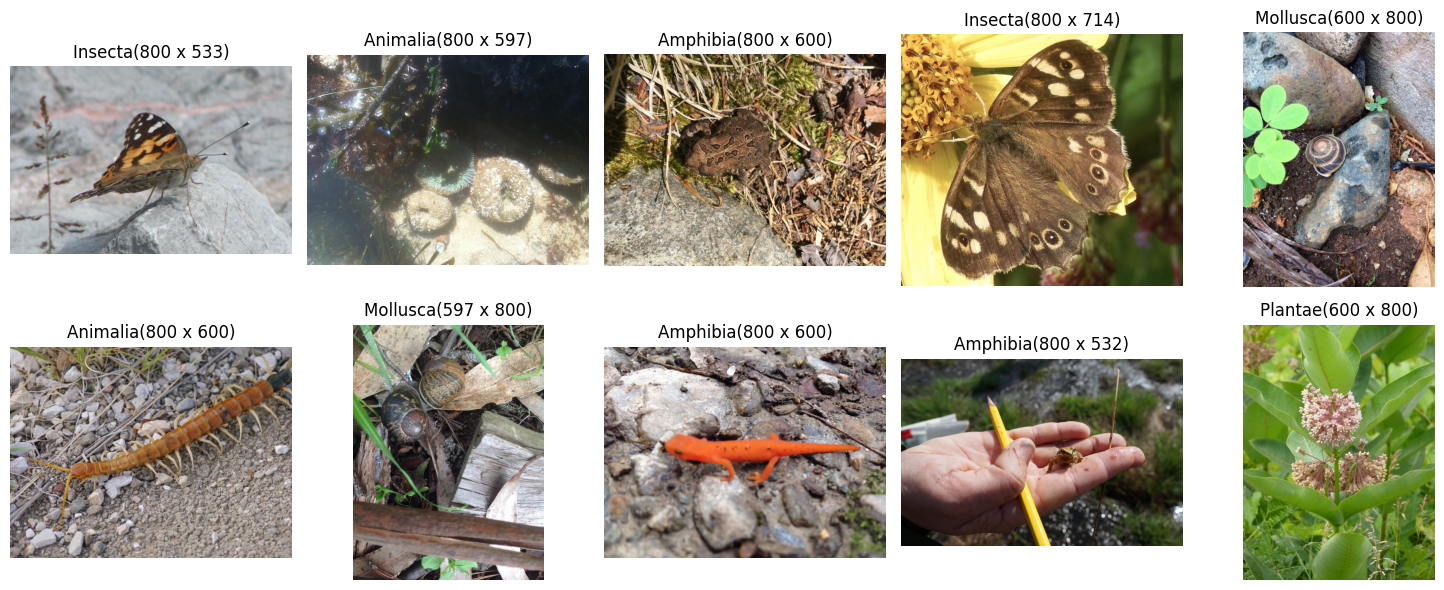

In [6]:
image_paths = []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.endswith(image_extensions):
            image_paths.append(os.path.join(root,file))

# print(image_paths)

# 10 random images
example_imgs = random.sample(image_paths, 10)

fig, axes = plt.subplots(2,5, figsize = (15,6))

for ax, img_path in zip(axes.ravel(),example_imgs):
    img = Image.open(img_path)
    # img.show()
    ax.imshow(img)

    width, height = img.size
    
    cls_name = os.path.basename(os.path.dirname(img_path))

    title = cls_name + '(' + str(width) + ' x ' + str(height) + ')'
    ax.set_title(title)
    
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# min_w = float('inf')
# max_w = 0
# min_h = float('inf')
# max_h = 0

# for path in image_paths:
#     with Image.open(path) as img:
#         w, h = img.size

#     min_w = min(min_w, w)
#     max_w = max(max_w, w)
#     min_h = min(min_h, h)
#     max_h = max(max_h, h)

# print(min_w, max_w)
# print(min_h, max_h)

In [8]:
# creating class to index

classes = sorted(os.listdir(train_path))

cls_to_idx = {}
for idx, cls in enumerate(classes):
    cls_to_idx[cls] = idx

cls_to_idx

{'Amphibia': 0,
 'Animalia': 1,
 'Arachnida': 2,
 'Aves': 3,
 'Fungi': 4,
 'Insecta': 5,
 'Mammalia': 6,
 'Mollusca': 7,
 'Plantae': 8,
 'Reptilia': 9}

In [9]:
# creating samples - tuple of image path and class index

samples = []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.endswith(image_extensions):

            cls_name = os.path.basename(root)
            cls_idx = cls_to_idx[cls_name]
            samples.append((os.path.join(root,file), cls_idx))

len(samples)


9999

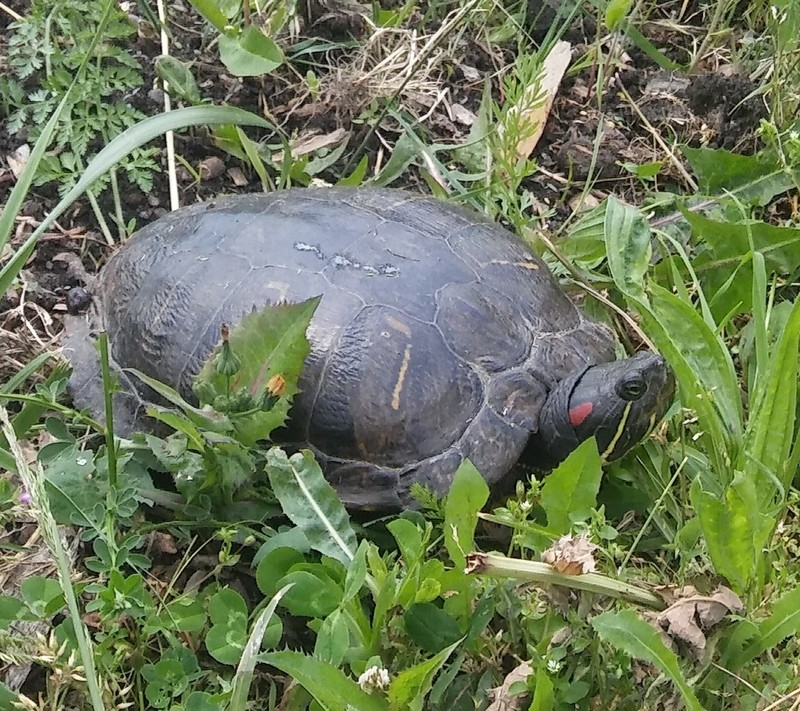

In [10]:
path, label = samples[9020]
Image.open(path)

In [11]:
# defining the transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def get_item(idx):
    path, label = samples[idx]

    img = Image.open(path)
    img = transform(img)

    return img, label

In [12]:
img, label = get_item(0)

print(type(img))
print(label)
img.shape

<class 'torch.Tensor'>
0


torch.Size([3, 224, 224])

In [13]:
class INaturalistDataset(Dataset):
    def __init__(self, train_path, transform = None):
        self.transform = transform
        
        self.cls_to_idx = {}

        # creating class to index
        classes = sorted(os.listdir(train_path))

        for idx, cls in enumerate(classes):
            self.cls_to_idx[cls] = idx

        self.samples = []
        for root, dirs, files in os.walk(train_path):
            for file in files:
                if file.endswith(image_extensions):

                    cls_name = os.path.basename(root)
                    cls_idx = self.cls_to_idx[cls_name]
                    self.samples.append((os.path.join(root,file), cls_idx))
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label
        

In [14]:
train_dataset = INaturalistDataset(train_path, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [16]:
from src.dataset import get_loaders

train_loader, val_loader, test_loader = get_loaders(
    train_path,
    val_path
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [22]:
from src.model import CNN

model = CNN(filters=[32,64,128,64,32])
total_params = sum(p.numel() for p in model.parameters())

print(total_params)

387626


In [23]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay=1e-4)

running_loss = 0
correct = 0
total = 0



In [24]:
model.train()

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    
    # forward pass
    outputs = model(images)

    # loss calc
    loss = criterion(outputs, labels)

    # backward
    loss.backward()
    optimizer.step()


    predictions = outputs.argmax(dim=1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0) 
    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)

epoch_acc = correct / total

print(epoch_loss)
print(epoch_acc)


2.2702354192733765
0.13551693961745218


In [25]:
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linea

In [26]:
total = 0
correct = 0
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0) 

print(correct/total)

0.186
